# 04 — Classification Model Training

**Goal:** Derive the "best algorithm per input profile" label from measured
execution-time data, train classification models to recommend an algorithm
given a profile (without leaking `algorithm` itself as a feature), and
investigate how often the "best" label is unstable due to small timing
margins between competing algorithms.

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

unified_df = pd.read_csv("../data/processed/unified_dataset.csv")
print(unified_df.shape)
unified_df.head()

(64780, 18)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25868\3016339099.py:17: DtypeWarning: Columns (0: found) have mixed types. Specify dtype option on import or set low_memory=False.
  unified_df = pd.read_csv("../data/processed/unified_dataset.csv")


,algorithm,input_size,input_condition,trial_id,comparisons,swaps_or_shifts,time_taken,memory_used,presortedness_score,duplicate_ratio,value_range,domain,probes,found,load_factor,collision_count,is_hashing,config_id
0,bubble_sort,10,random,1,44.0,30.0,0.000039,416,0.3333,0.0,88143.0,sorting,0.0,NaN,NaN,0.0,0,sorting_bubble_sort_10_random
1,selection_sort,10,random,1,45.0,8.0,0.000025,416,0.3333,0.0,88143.0,sorting,0.0,NaN,NaN,0.0,0,sorting_selection_sort_10_random
2,insertion_sort,10,random,1,36.0,30.0,0.000026,416,0.3333,0.0,88143.0,sorting,0.0,NaN,NaN,0.0,0,sorting_insertion_sort_10_random
3,merge_sort,10,random,1,22.0,34.0,0.000074,416,0.3333,0.0,88143.0,sorting,0.0,NaN,NaN,0.0,0,sorting_merge_sort_10_random
4,quick_sort,10,random,1,29.0,24.0,0.000072,416,0.3333,0.0,88143.0,sorting,0.0,NaN,NaN,0.0,0,sorting_quick_sort_10_random


In [3]:
profile_cols = ["domain", "input_size", "input_condition"]

profile_algo_times = (
    unified_df
    .groupby(profile_cols + ["algorithm"])["time_taken"]
    .mean()
    .reset_index()
)

print(profile_algo_times.shape)
profile_algo_times.head(10)

(13000, 5)


,domain,input_size,input_condition,algorithm,time_taken
0,searching,10,average_case,binary_search,0.000021
1,searching,10,average_case,exponential_search,0.000025
2,searching,10,average_case,fibonacci_search,0.000021
3,searching,10,average_case,hashing_search,0.000064
4,searching,10,average_case,interpolation_search,0.000026
5,searching,10,average_case,linear_search,0.000017
6,searching,10,best_case,binary_search,0.000021
7,searching,10,best_case,exponential_search,0.000024
8,searching,10,best_case,fibonacci_search,0.000017
9,searching,10,best_case,hashing_search,0.000074


In [4]:
def get_best_and_second(group):
    sorted_group = group.sort_values("time_taken")
    best_algo = sorted_group.iloc[0]["algorithm"]
    best_time = sorted_group.iloc[0]["time_taken"]
    second_algo = sorted_group.iloc[1]["algorithm"] if len(sorted_group) > 1 else None
    second_time = sorted_group.iloc[1]["time_taken"] if len(sorted_group) > 1 else None
    return pd.Series({
        "best_algorithm": best_algo,
        "best_time": best_time,
        "second_algorithm": second_algo,
        "second_time": second_time,
    })

profile_labels = (
    profile_algo_times
    .groupby(profile_cols)
    .apply(get_best_and_second)
    .reset_index()
)

print(profile_labels.shape)
profile_labels.head(10)

(2000, 7)


,domain,input_size,input_condition,best_algorithm,best_time,second_algorithm,second_time
0,searching,10,average_case,linear_search,0.000017,fibonacci_search,0.000021
1,searching,10,best_case,fibonacci_search,0.000017,binary_search,0.000021
2,searching,10,duplicates_present,linear_search,0.000018,fibonacci_search,0.000019
3,searching,10,not_found,linear_search,0.000015,binary_search,0.000015
4,searching,10,worst_case,linear_search,0.000015,interpolation_search,0.000017
5,searching,20,average_case,linear_search,0.000016,exponential_search,0.000018
6,searching,20,best_case,linear_search,0.000014,fibonacci_search,0.000015
7,searching,20,duplicates_present,linear_search,0.000025,binary_search,0.000027
8,searching,20,not_found,interpolation_search,0.000014,binary_search,0.000021
9,searching,20,worst_case,linear_search,0.000016,interpolation_search,0.000021


In [5]:
profile_labels["absolute_margin"] = profile_labels["second_time"] - profile_labels["best_time"]
profile_labels["relative_margin"] = profile_labels["absolute_margin"] / profile_labels["best_time"]

profile_labels[["domain", "input_size", "input_condition", "best_algorithm",
                 "second_algorithm", "absolute_margin", "relative_margin"]].head(10)

,domain,input_size,input_condition,best_algorithm,second_algorithm,absolute_margin,relative_margin
0,searching,10,average_case,linear_search,fibonacci_search,3.340000e-06,0.192175
1,searching,10,best_case,fibonacci_search,binary_search,3.220000e-06,0.186343
2,searching,10,duplicates_present,linear_search,fibonacci_search,2.600013e-07,0.014054
3,searching,10,not_found,linear_search,binary_search,3.199995e-07,0.021390
4,searching,10,worst_case,linear_search,interpolation_search,1.560000e-06,0.104139
5,searching,20,average_case,linear_search,exponential_search,2.280001e-06,0.144670
6,searching,20,best_case,linear_search,fibonacci_search,6.400012e-07,0.044755
7,searching,20,duplicates_present,linear_search,binary_search,1.780000e-06,0.070691
8,searching,20,not_found,interpolation_search,binary_search,6.999999e-06,0.502874
9,searching,20,worst_case,linear_search,interpolation_search,4.599999e-06,0.288582


count    2000.000000
mean        0.566242
std         0.663217
min         0.000089
25%         0.188277
50%         0.477406
75%         0.733856
max        11.336207
Name: relative_margin, dtype: float64


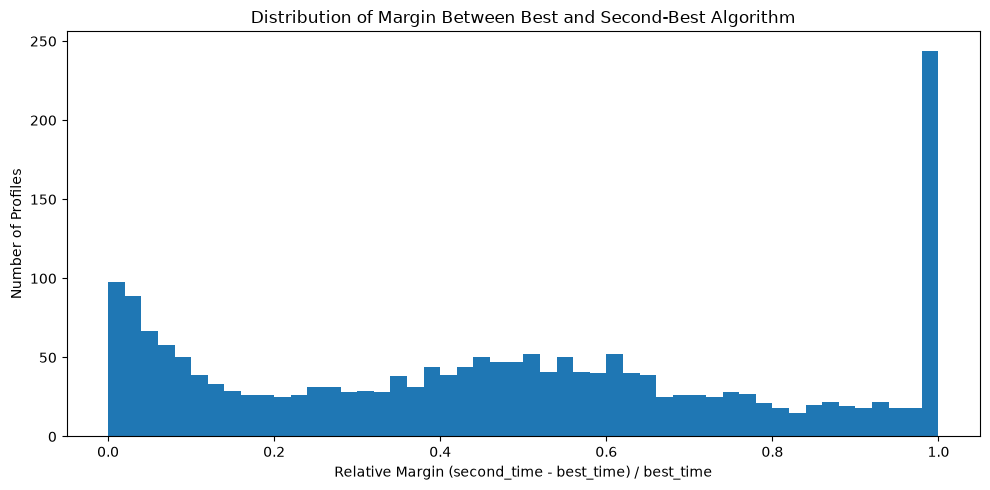

In [6]:
print(profile_labels["relative_margin"].describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(profile_labels["relative_margin"].clip(upper=1.0), bins=50)
ax.set_xlabel("Relative Margin (second_time - best_time) / best_time")
ax.set_ylabel("Number of Profiles")
ax.set_title("Distribution of Margin Between Best and Second-Best Algorithm")
plt.tight_layout()
plt.savefig("../visualizations/margin_distribution.png", dpi=150)
plt.show()

In [7]:
thresholds = [0.01, 0.05, 0.10, 0.20]
for t in thresholds:
    pct = (profile_labels["relative_margin"] <= t).mean() * 100
    print(f"Profiles with relative margin <= {t*100:.0f}%: {pct:.1f}%")

Profiles with relative margin <= 1%: 2.5%
Profiles with relative margin <= 5%: 10.9%
Profiles with relative margin <= 10%: 18.1%
Profiles with relative margin <= 20%: 25.8%


## Margin Analysis — Findings

Across all 2000 unique input profiles, the relative margin between the best
and second-best algorithm varies widely (min 0.01%, median 47.7%, max 1134%).
However, a meaningful subset of profiles show very tight competition:

- 2.5% of profiles have a margin <= 1%
- 10.9% of profiles have a margin <= 5%
- 18.1% of profiles have a margin <= 10%
- 25.8% of profiles have a margin <= 20%

**Threshold chosen: 10%.** Profiles with a relative margin at or below 10%
are treated as "close calls" -- competition where the best-algorithm label
is plausibly unstable to trial-level timing noise, since a shift of that
size is well within the kind of variance seen across repeated trials of the
same configuration. This affects roughly 1 in 6 profiles (18.1%) and forms
the empirical basis for the predictability-gap discussion: these are the
profiles where we'd expect the classifier to struggle most, and where
"predict execution time" is inherently more reliable than "predict the
single best label."

In [8]:
profile_labels["is_close_call"] = profile_labels["relative_margin"] <= 0.10
print(profile_labels["is_close_call"].value_counts())

is_close_call
False    1638
True      362
Name: count, dtype: int64


In [9]:
classification_df = profile_labels[profile_cols + ["best_algorithm"]].copy()

print(classification_df.shape)
classification_df.head()

(2000, 4)


,domain,input_size,input_condition,best_algorithm
0,searching,10,average_case,linear_search
1,searching,10,best_case,fibonacci_search
2,searching,10,duplicates_present,linear_search
3,searching,10,not_found,linear_search
4,searching,10,worst_case,linear_search


In [10]:
print(classification_df["best_algorithm"].value_counts())

best_algorithm
radix_sort              734
linear_search           690
bubble_sort             200
interpolation_search    123
fibonacci_search        107
exponential_search       53
insertion_sort           53
binary_search            27
quick_sort                9
selection_sort            4
Name: count, dtype: int64


## Class Balance — Findings

Of the 13 algorithms, only 10 ever appear as `best_algorithm` across the
2000 profiles. `merge_sort`, `heap_sort`, and `hashing_search` never win a
single profile. The distribution among the 10 that do win is heavily
skewed: `radix_sort` (734, 36.7%) and `linear_search` (690, 34.5%) together
account for over 70% of all best-algorithm labels, while `selection_sort`
(4) and `quick_sort` (9) win almost never.

This severe class imbalance means accuracy alone is a poor evaluation
metric -- a trivial classifier that always predicts radix_sort or
linear_search would score ~36% accuracy without learning anything
meaningful, and a classifier that never predicts the 3 absent classes is
not failing, it is correctly reflecting the data. Macro F1 is used
alongside accuracy to surface this imbalance rather than hide it.

In [11]:
profile_features = (
    unified_df
    .groupby(profile_cols)[["presortedness_score", "duplicate_ratio", "value_range", "collision_count"]]
    .mean()
    .reset_index()
)

classification_df = classification_df.merge(profile_features, on=profile_cols, how="left")

print(classification_df.shape)
classification_df.head()

(2000, 8)


,domain,input_size,input_condition,best_algorithm,presortedness_score,duplicate_ratio,value_range,collision_count
0,searching,10,average_case,linear_search,0.0,0.0,0.0,0.933333
1,searching,10,best_case,fibonacci_search,0.0,0.0,0.0,0.933333
2,searching,10,duplicates_present,linear_search,0.0,0.0,0.0,0.900000
3,searching,10,not_found,linear_search,0.0,0.0,0.0,0.931034
4,searching,10,worst_case,linear_search,0.0,0.0,0.0,0.833333


In [12]:
profile_features = (
    unified_df
    .groupby(profile_cols)[["presortedness_score", "duplicate_ratio", "value_range"]]
    .mean()
    .reset_index()
)

classification_df = profile_labels[profile_cols + ["best_algorithm"]].merge(
    profile_features, on=profile_cols, how="left"
)

print(classification_df.shape)
classification_df.head(10)

(2000, 7)


,domain,input_size,input_condition,best_algorithm,presortedness_score,duplicate_ratio,value_range
0,searching,10,average_case,linear_search,0.0,0.0,0.0
1,searching,10,best_case,fibonacci_search,0.0,0.0,0.0
2,searching,10,duplicates_present,linear_search,0.0,0.0,0.0
3,searching,10,not_found,linear_search,0.0,0.0,0.0
4,searching,10,worst_case,linear_search,0.0,0.0,0.0
5,searching,20,average_case,linear_search,0.0,0.0,0.0
6,searching,20,best_case,linear_search,0.0,0.0,0.0
7,searching,20,duplicates_present,linear_search,0.0,0.0,0.0
8,searching,20,not_found,interpolation_search,0.0,0.0,0.0
9,searching,20,worst_case,linear_search,0.0,0.0,0.0


In [13]:
classification_df[classification_df["domain"] == "sorting"].head(10)


,domain,input_size,input_condition,best_algorithm,presortedness_score,duplicate_ratio,value_range
1000,sorting,10,duplicates,insertion_sort,0.39556,0.30,72507.2
1001,sorting,10,nearly_sorted,insertion_sort,0.83554,0.00,85965.0
1002,sorting,10,random,insertion_sort,0.40444,0.00,86332.0
1003,sorting,10,reverse_sorted,selection_sort,0.00000,0.00,89606.6
1004,sorting,10,sorted,bubble_sort,1.00000,0.00,81176.2
1005,sorting,20,duplicates,insertion_sort,0.55790,0.55,73177.2
1006,sorting,20,nearly_sorted,insertion_sort,0.95684,0.00,93022.0
1007,sorting,20,random,insertion_sort,0.49894,0.00,91457.8
1008,sorting,20,reverse_sorted,selection_sort,0.00000,0.00,91238.4
1009,sorting,20,sorted,bubble_sort,1.00000,0.00,90716.0


In [14]:
classification_categorical = ["domain", "input_condition"]
classification_numerical = ["input_size", "presortedness_score", "duplicate_ratio", "value_range"]

X_clf = classification_df[classification_numerical + classification_categorical]
y_clf = classification_df["best_algorithm"]

print(X_clf.shape, y_clf.shape)
print(y_clf.value_counts())

(2000, 6) (2000,)
best_algorithm
radix_sort              734
linear_search           690
bubble_sort             200
interpolation_search    123
fibonacci_search        107
exponential_search       53
insertion_sort           53
binary_search            27
quick_sort                9
selection_sort            4
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

class_counts = y_clf.value_counts()
print(class_counts)
print("\nClasses with fewer than 5 instances:", class_counts[class_counts < 5].index.tolist())

best_algorithm
radix_sort              734
linear_search           690
bubble_sort             200
interpolation_search    123
fibonacci_search        107
exponential_search       53
insertion_sort           53
binary_search            27
quick_sort                9
selection_sort            4
Name: count, dtype: int64

Classes with fewer than 5 instances: ['selection_sort']


In [16]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print("Train shape:", X_train_clf.shape)
print("Test shape:", X_test_clf.shape)
print("\nTrain class distribution:\n", y_train_clf.value_counts())
print("\nTest class distribution:\n", y_test_clf.value_counts())

Train shape: (1600, 6)
Test shape: (400, 6)

Train class distribution:
 best_algorithm
radix_sort              586
linear_search           546
bubble_sort             155
interpolation_search    101
fibonacci_search         87
insertion_sort           48
exponential_search       46
binary_search            21
quick_sort                6
selection_sort            4
Name: count, dtype: int64

Test class distribution:
 best_algorithm
radix_sort              148
linear_search           144
bubble_sort              45
interpolation_search     22
fibonacci_search         20
exponential_search        7
binary_search             6
insertion_sort            5
quick_sort                3
Name: count, dtype: int64


## Classification Train/Test Split

Unlike regression, there is no repeated-trial leakage risk here since
`classification_df` is already one row per unique profile. However, class
imbalance is severe enough that a stratified split is not viable:
`selection_sort` has only 4 total instances (below sklearn's minimum for
stratification), and `quick_sort` has only 9.

**Decision:** a plain (non-stratified) random split is used, with a fixed
seed for reproducibility. This means the rarest classes may end up
under-represented or entirely absent from the test set by chance -- this is
disclosed explicitly rather than hidden, and is itself part of the
predictability-gap discussion: an algorithm that wins as "best" only 3-9
times across 2000 profiles cannot be reliably learned or evaluated by any
classifier, regardless of split strategy.

## Observed Split Outcome

As anticipated, `selection_sort` (4 total instances) landed entirely in the
training set, with zero instances in test -- it cannot be evaluated at all
in this run. `quick_sort` (9 total) split 6/3. Both reflect a genuine data
characteristic: these algorithms almost never register as "best" across the
2000 profiles, so no split strategy could guarantee reliable train+test
coverage for them. This is disclosed as a known limitation of the
classification task, not fixed artificially (e.g. by oversampling or
duplicating profiles), since doing so would fabricate evidence the dataset
does not actually contain.

In [17]:
clf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), classification_numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), classification_categorical),
    ]
)

logreg_pipeline = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

rf_clf_pipeline = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

print("Classification pipelines built.")

Classification pipelines built.


In [18]:
logreg_pipeline.fit(X_train_clf, y_train_clf)
print("Logistic Regression trained.")

rf_clf_pipeline.fit(X_train_clf, y_train_clf)
print("Random Forest Classifier trained.")

Logistic Regression trained.
Random Forest Classifier trained.


In [19]:
logreg_preds = logreg_pipeline.predict(X_test_clf)
rf_clf_preds = rf_clf_pipeline.predict(X_test_clf)

print("Predictions generated.")

Predictions generated.


In [20]:
def evaluate_clf(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return {"Model": label, "Accuracy": acc, "Macro F1": f1_macro, "Weighted F1": f1_weighted}

clf_results = [
    evaluate_clf(y_test_clf, logreg_preds, "Logistic Regression"),
    evaluate_clf(y_test_clf, rf_clf_preds, "Random Forest"),
]

clf_results_df = pd.DataFrame(clf_results)
clf_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.905,0.510341,0.868406
1,Random Forest,0.875,0.596817,0.875685


In [21]:
print("=== Random Forest Classification Report ===")
print(classification_report(y_test_clf, rf_clf_preds, zero_division=0))

=== Random Forest Classification Report ===
                      precision    recall  f1-score   support

       binary_search       0.50      0.17      0.25         6
         bubble_sort       1.00      1.00      1.00        45
  exponential_search       0.23      0.43      0.30         7
    fibonacci_search       0.29      0.35      0.32        20
      insertion_sort       0.83      1.00      0.91         5
interpolation_search       0.70      0.73      0.71        22
       linear_search       0.91      0.87      0.89       144
          quick_sort       0.00      0.00      0.00         3
          radix_sort       0.99      1.00      0.99       148

            accuracy                           0.88       400
           macro avg       0.61      0.62      0.60       400
        weighted avg       0.88      0.88      0.88       400



## Classification Model Selection

Random Forest is selected over Logistic Regression based on **macro F1**
(0.597 vs 0.510), not accuracy (0.875 vs 0.905). Logistic Regression's
higher accuracy is a byproduct of severe class imbalance -- `radix_sort`
and `linear_search` alone make up 73% of test profiles, so a model that
leans harder into predicting these two dominant classes will score higher
on accuracy while actually generalizing worse across the full algorithm
set. Macro F1 treats every class equally, correctly surfacing this
trade-off.

## Per-Class Findings

The per-class report reveals a pattern that directly supports the
predictability-gap thesis: algorithms with clearly dominant or clearly
weak performance profiles (`radix_sort` F1=0.99, `bubble_sort` F1=1.00,
`linear_search` F1=0.89) are classified reliably, while algorithms locked
in close competition with similar-performing alternatives
(`exponential_search` F1=0.30, `fibonacci_search` F1=0.32,
`binary_search` F1=0.25) are classified poorly. `quick_sort` fails
entirely (F1=0.00, only 3 test instances) and `selection_sort` could not
be evaluated at all (0 test instances). This is direct evidence that
classification difficulty correlates with how close the competing
algorithms' execution times are -- exactly the phenomenon quantified in
the margin analysis above.

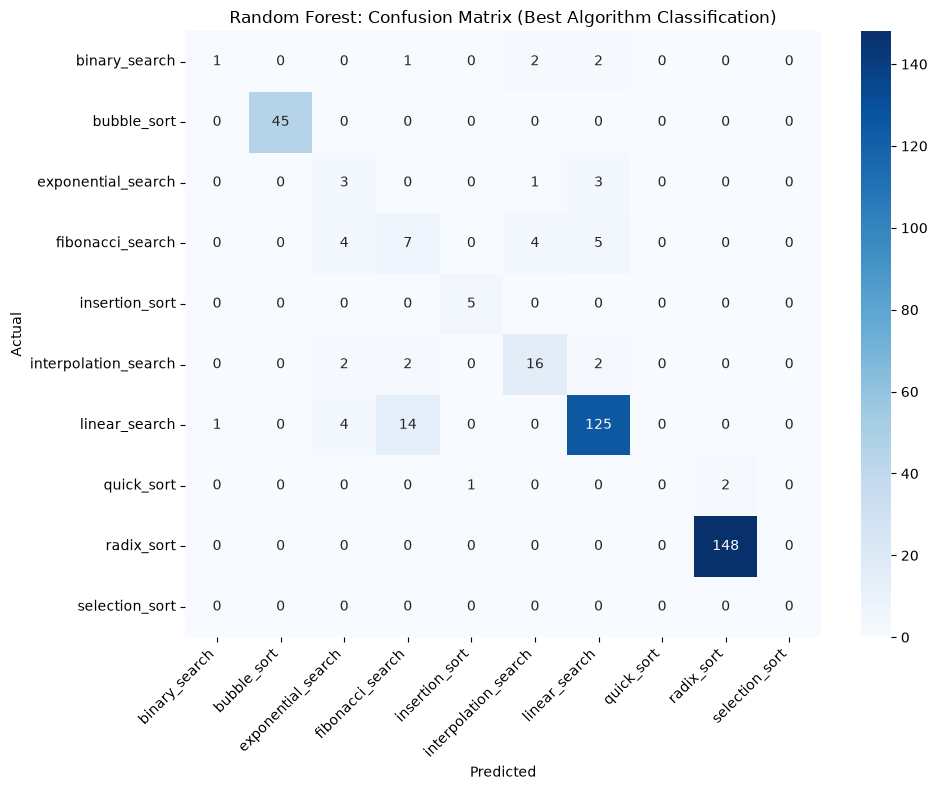

In [22]:
labels_order = sorted(y_clf.unique())
cm = confusion_matrix(y_test_clf, rf_clf_preds, labels=labels_order)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest: Confusion Matrix (Best Algorithm Classification)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visualizations/confusion_matrix.png", dpi=150)
plt.show()

## Confusion Matrix — Findings

Misclassification is almost entirely confined to a single cluster: `binary_search`,
`exponential_search`, `fibonacci_search`, `interpolation_search`, and
`linear_search` are frequently confused with one another, while `bubble_sort`
(45/45), `radix_sort` (148/148), and `insertion_sort` (5/5) are classified with
zero errors. No sorting algorithm is ever confused with a searching algorithm
(the two domains have entirely different execution-time scales).

This pattern is not random noise -- the confused cluster consists precisely of
the sub-linear/linear-complexity searching algorithms that competed within thin
timing margins in the margin analysis above. Algorithms with a clearly dominant
or clearly weak performance profile relative to their competitors are learned
perfectly; algorithms in genuinely close competition are the ones the classifier
struggles with. This is strong, direct visual evidence for the predictability-gap
thesis: the difficulty is not evenly distributed, it concentrates exactly where
algorithm performance is genuinely close.

In [24]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_clf_pipeline, "../models/classification_model.pkl")
print("Classification model saved to models/classification_model.pkl")

Classification model saved to models/classification_model.pkl
